# 2. Trenowanie klasyfikatorów

Tu już nie ma geometrii — biorę gotowy dataset po feature engineeringu
(`data/processed/ifc_features.csv`) i próbuję kilku modeli, które mają
zgadywać klasę elementu (Beam/Slab/Stair/Wall) na podstawie samych cech
geometrycznych.

In [1]:
%matplotlib inline
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
DATA_CSV = ROOT / "data" / "processed" / "ifc_features.csv"
MODELS_DIR = ROOT / "models"
REPORTS_DIR = ROOT / "reports"
MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

NON_FEATURE_COLS = ["file", "split", "label", "stored_ifc_class", "type_mismatch", "guid", "name"]

In [2]:
df = pd.read_csv(DATA_CSV)
feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]
train = df[df["split"] == "train"]
test = df[df["split"] == "test"]
labels = sorted(df["label"].unique())

X_train, y_train = train[feature_cols].values, train["label"].values
X_test, y_test = test[feature_cols].values, test["label"].values

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"train rows: {len(train)}, test rows: {len(test)}, features: {len(feature_cols)}")
train["label"].value_counts()

train rows: 965, test rows: 413, features: 39


label
Wall     376
Slab     355
Beam     198
Stair     36
Name: count, dtype: int64

In [3]:
def evaluate(name, y_true, y_pred, labels):
    report = classification_report(y_true, y_pred, labels=labels, digits=3)
    print(f"=== {name} ===")
    print(report)
    (REPORTS_DIR / f"classification_report_{name}.txt").write_text(report, encoding="utf-8")

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion matrix - {name}")
    fig.tight_layout()
    fig.savefig(REPORTS_DIR / f"confusion_matrix_{name}.png", dpi=150)
    plt.show()

## Baseline

Zanim zacznę cokolwiek trenować na serio, robię sobie punkt odniesienia:
`DummyClassifier` losujący klasę zgodnie z rozkładem klas w treningu. Każdy
prawdziwy model musi go wyraźnie przebić, inaczej po co się męczyć.

=== baseline ===
              precision    recall  f1-score   support

        Beam      0.189     0.214     0.201        84
        Slab      0.388     0.355     0.371       152
       Stair      0.000     0.000     0.000        16
        Wall      0.427     0.453     0.440       161

    accuracy                          0.351       413
   macro avg      0.251     0.256     0.253       413
weighted avg      0.348     0.351     0.349       413



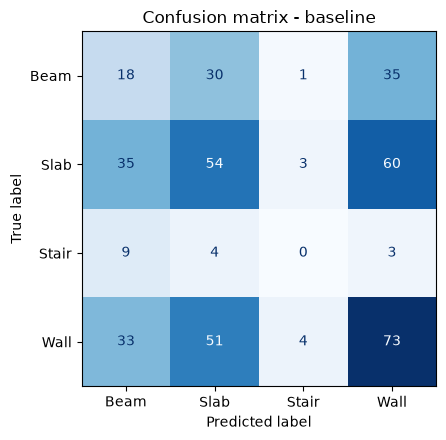

In [4]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="stratified", random_state=42)
baseline.fit(X_train, y_train)
evaluate("baseline", y_test, baseline.predict(X_test), labels)

## Random Forest

=== random_forest ===
              precision    recall  f1-score   support

        Beam      0.926     0.893     0.909        84
        Slab      0.943     0.974     0.958       152
       Stair      1.000     1.000     1.000        16
        Wall      0.987     0.975     0.981       161

    accuracy                          0.959       413
   macro avg      0.964     0.960     0.962       413
weighted avg      0.959     0.959     0.959       413



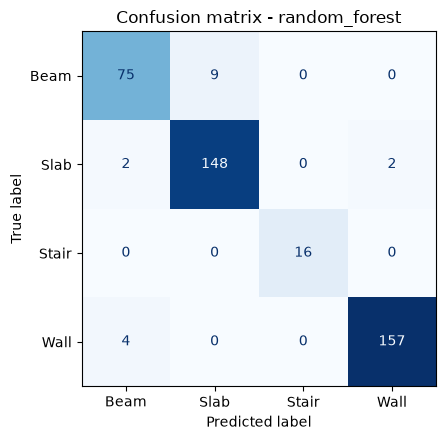

In [5]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
evaluate("random_forest", y_test, rf.predict(X_test), labels)

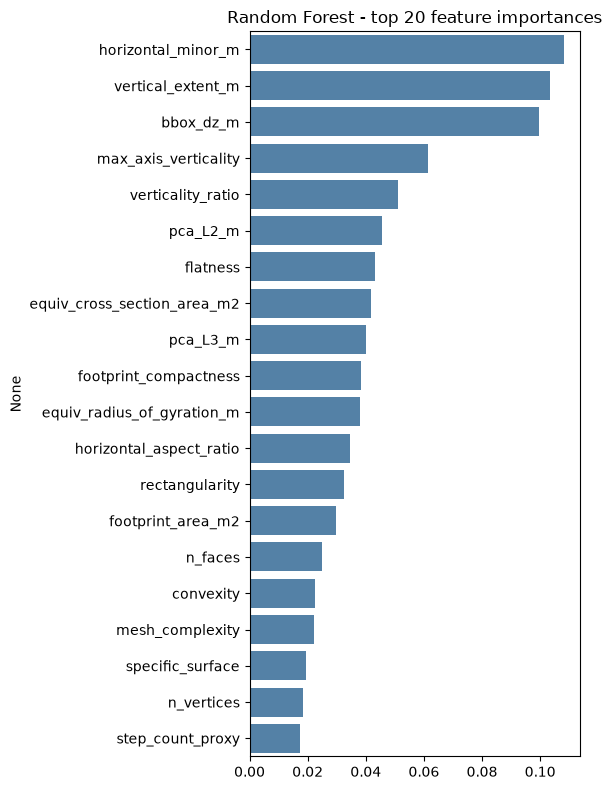

horizontal_minor_m             0.108290
vertical_extent_m              0.103501
bbox_dz_m                      0.099643
max_axis_verticality           0.061400
verticality_ratio              0.051101
pca_L2_m                       0.045726
flatness                       0.043107
equiv_cross_section_area_m2    0.041829
pca_L3_m                       0.039907
footprint_compactness          0.038186
dtype: float64

In [6]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 8))
sns.barplot(x=importances.values[:20], y=importances.index[:20], ax=ax, color="steelblue")
ax.set_title("Random Forest - top 20 feature importances")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "feature_importances_rf.png", dpi=150)
plt.show()

importances.to_csv(REPORTS_DIR / "feature_importances_rf.csv")
importances.head(10)

### Hyperparameter tuning (GridSearchCV) — Random Forest

Przeszukuję siatkę hiperparametrów z 5-fold cross-validation, żeby
sprawdzić, czy ręcznie dobrane `n_estimators=400, max_depth=None` da się
jeszcze poprawić.

In [7]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold

tuning_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 12, 20],
    "min_samples_leaf": [1, 2, 4],
}
grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_grid, cv=tuning_cv, scoring="accuracy", n_jobs=-1,
)
grid.fit(X_train, y_train)

print(f"best CV accuracy: {grid.best_score_:.4f}")
print(f"best params: {grid.best_params_}")
print(f"manually-tuned RF (n_estimators=400, max_depth=None): "
      f"test accuracy {accuracy_score(y_test, rf.predict(X_test)):.4f}")
print(f"GridSearchCV best estimator: test accuracy "
      f"{accuracy_score(y_test, grid.best_estimator_.predict(X_test)):.4f}")

best CV accuracy: 0.9658
best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
manually-tuned RF (n_estimators=400, max_depth=None): test accuracy 0.9588
GridSearchCV best estimator: test accuracy 0.9588


## MLP

=== mlp ===
              precision    recall  f1-score   support

        Beam      0.905     0.798     0.848        84
        Slab      0.913     0.967     0.939       152
       Stair      1.000     1.000     1.000        16
        Wall      0.963     0.969     0.966       161

    accuracy                          0.935       413
   macro avg      0.945     0.933     0.938       413
weighted avg      0.934     0.935     0.933       413



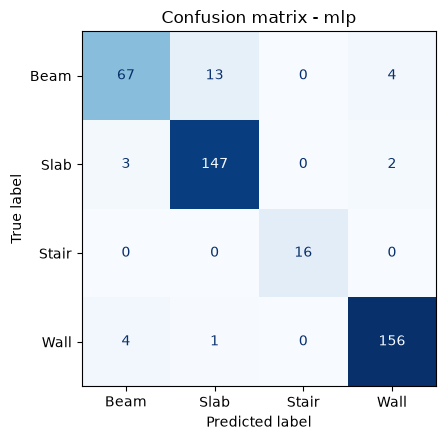

In [8]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    alpha=1e-3,
    max_iter=3000,
    early_stopping=True,
    random_state=42,
)
mlp.fit(X_train_s, y_train)
evaluate("mlp", y_test, mlp.predict(X_test_s), labels)

## Gradient Boosting

=== gradient_boosting ===
              precision    recall  f1-score   support

        Beam      0.939     0.917     0.928        84
        Slab      0.961     0.974     0.967       152
       Stair      1.000     1.000     1.000        16
        Wall      0.981     0.981     0.981       161

    accuracy                          0.966       413
   macro avg      0.970     0.968     0.969       413
weighted avg      0.966     0.966     0.966       413



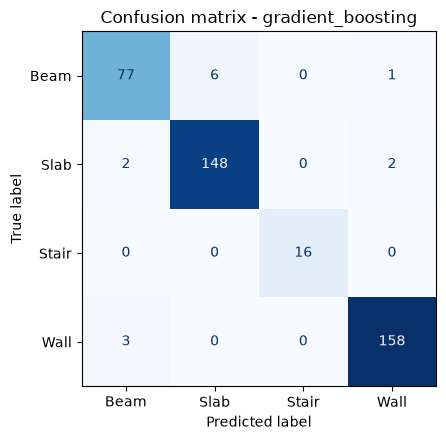

In [9]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
)
gb.fit(X_train, y_train)
evaluate("gradient_boosting", y_test, gb.predict(X_test), labels)

## Logistic Regression

=== logistic_regression ===
              precision    recall  f1-score   support

        Beam      0.904     0.893     0.898        84
        Slab      0.942     0.954     0.948       152
       Stair      0.941     1.000     0.970        16
        Wall      0.987     0.975     0.981       161

    accuracy                          0.952       413
   macro avg      0.943     0.955     0.949       413
weighted avg      0.952     0.952     0.952       413



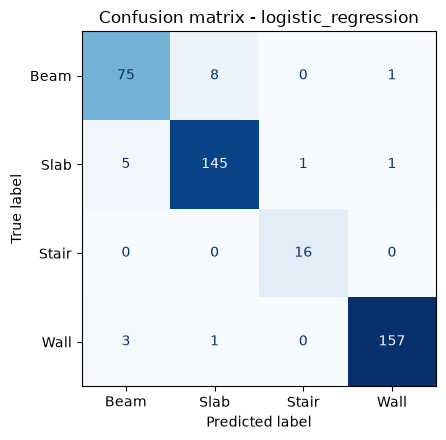

In [10]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42,
)
logreg.fit(X_train_s, y_train)
evaluate("logistic_regression", y_test, logreg.predict(X_test_s), labels)

## Diagnostyka

Sprawdzam cztery rzeczy: (1) różnicę train vs test accuracy, (2) krzywe
uczenia (train/walidacja w funkcji liczby próbek), (3) krzywą walidacyjną
Random Forest w funkcji liczby drzew, (4) krzywą straty MLP w kolejnych
epokach.

                     train_accuracy  test_accuracy       gap
model                                                       
Baseline                   0.318135       0.351090 -0.032955
Logistic Regression        0.974093       0.951574  0.022519
Random Forest              0.998964       0.958838  0.040126
Gradient Boosting          1.000000       0.966102  0.033898
MLP                        0.973057       0.934625  0.038432


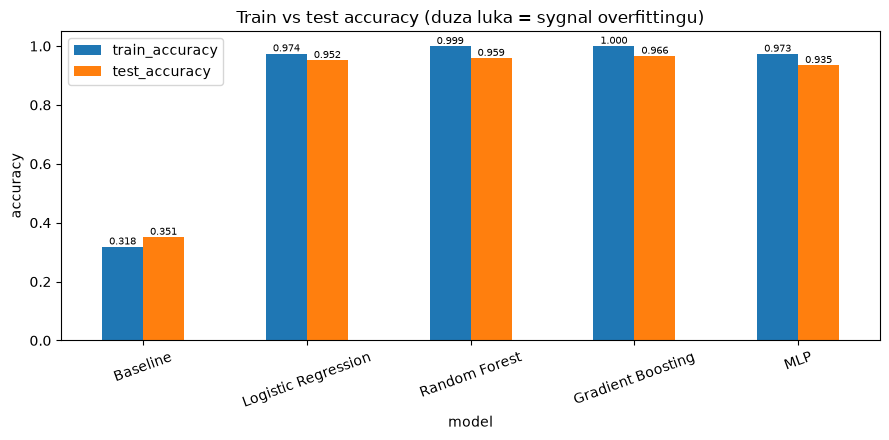

In [11]:
import numpy as np
from sklearn.metrics import accuracy_score

MODELS = [
    ("Baseline", baseline, X_train, X_test),
    ("Logistic Regression", logreg, X_train_s, X_test_s),
    ("Random Forest", rf, X_train, X_test),
    ("Gradient Boosting", gb, X_train, X_test),
    ("MLP", mlp, X_train_s, X_test_s),
]

acc_rows = []
for name, model, Xtr, Xte in MODELS:
    acc_rows.append({
        "model": name,
        "train_accuracy": accuracy_score(y_train, model.predict(Xtr)),
        "test_accuracy": accuracy_score(y_test, model.predict(Xte)),
    })
acc_df = pd.DataFrame(acc_rows).set_index("model")
acc_df["gap"] = acc_df["train_accuracy"] - acc_df["test_accuracy"]
print(acc_df)

ax = acc_df[["train_accuracy", "test_accuracy"]].plot(kind="bar", figsize=(9, 4.5), rot=20, ylim=(0, 1.05))
ax.set_ylabel("accuracy")
ax.set_title("Train vs test accuracy (duza luka = sygnal overfittingu)")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=7)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "train_vs_test_accuracy.png", dpi=150)
plt.show()

### Krzywe uczenia

Trenuję model wielokrotnie na coraz większej części danych treningowych
(z walidacją krzyżową 5-fold na zbiorze train) i patrzę, jak zmienia się
accuracy na próbce treningowej vs na foldzie walidacyjnym.

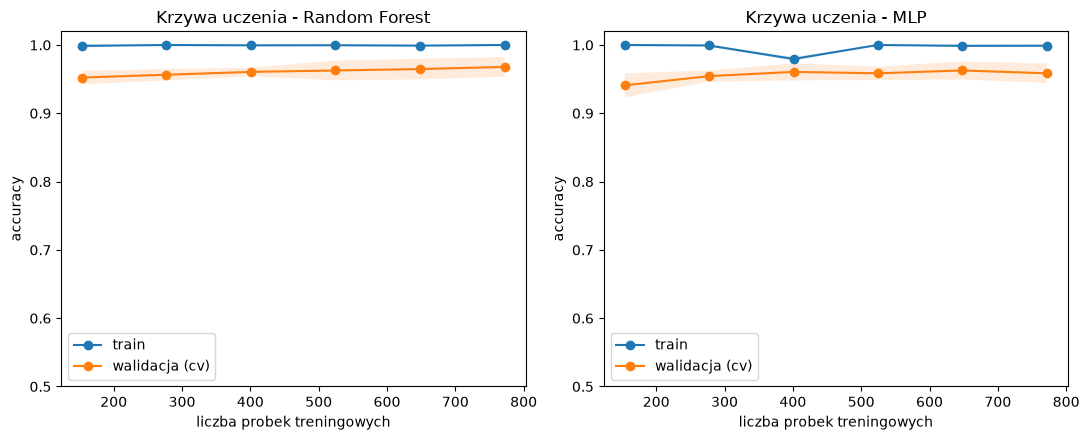

In [12]:
from sklearn.model_selection import StratifiedKFold, learning_curve

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.2, 1.0, 6)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, model, X, y, name in [
    (axes[0], RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=42, n_jobs=-1),
     X_train, y_train, "Random Forest"),
    (axes[1], MLPClassifier(hidden_layer_sizes=(64, 32), alpha=1e-3, max_iter=3000, random_state=42),
     X_train_s, y_train, "MLP"),
]:
    sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, train_sizes=train_sizes, scoring="accuracy", n_jobs=-1,
        shuffle=True, random_state=42,
    )
    ax.plot(sizes, train_scores.mean(axis=1), "o-", label="train")
    ax.plot(sizes, val_scores.mean(axis=1), "o-", label="walidacja (cv)")
    ax.fill_between(sizes, train_scores.mean(1) - train_scores.std(1), train_scores.mean(1) + train_scores.std(1), alpha=0.15)
    ax.fill_between(sizes, val_scores.mean(1) - val_scores.std(1), val_scores.mean(1) + val_scores.std(1), alpha=0.15)
    ax.set_title(f"Krzywa uczenia - {name}")
    ax.set_xlabel("liczba probek treningowych")
    ax.set_ylabel("accuracy")
    ax.set_ylim(0.5, 1.02)
    ax.legend()
fig.tight_layout()
fig.savefig(REPORTS_DIR / "learning_curves.png", dpi=150)
plt.show()

### Krzywa walidacyjna Random Forest

Sprawdzam, jak accuracy train/walidacja zmienia się wraz z `n_estimators`.

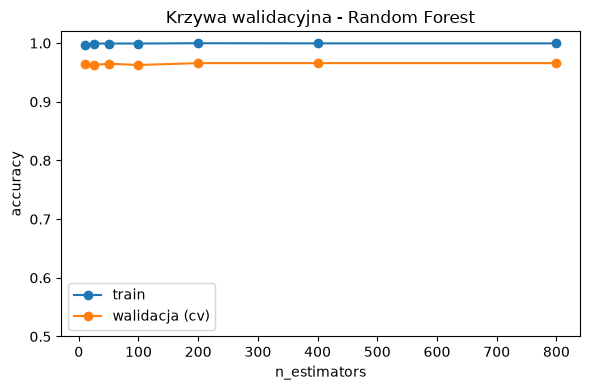

In [13]:
from sklearn.model_selection import validation_curve

param_range = [10, 25, 50, 100, 200, 400, 800]
train_scores, val_scores = validation_curve(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    X_train, y_train, param_name="n_estimators", param_range=param_range,
    cv=cv, scoring="accuracy", n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(param_range, train_scores.mean(axis=1), "o-", label="train")
ax.plot(param_range, val_scores.mean(axis=1), "o-", label="walidacja (cv)")
ax.set_xlabel("n_estimators")
ax.set_ylabel("accuracy")
ax.set_title("Krzywa walidacyjna - Random Forest")
ax.set_ylim(0.5, 1.02)
ax.legend()
fig.tight_layout()
fig.savefig(REPORTS_DIR / "validation_curve_rf.png", dpi=150)
plt.show()

### Krzywa straty MLP

`early_stopping=True` w MLP odkłada 10% danych treningowych jako wewnętrzny
zbiór walidacyjny i pilnuje `validation_scores_` w kolejnych epokach.

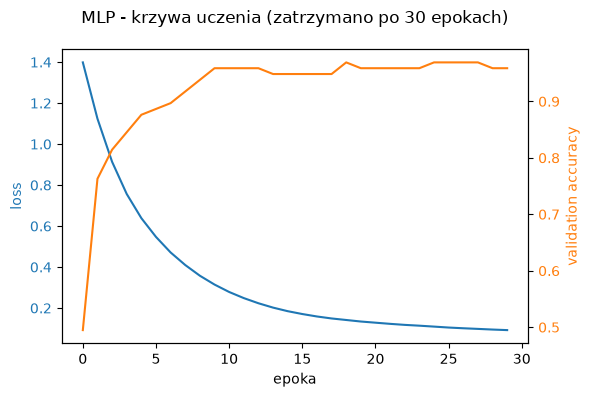

In [14]:
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(mlp.loss_curve_, color="tab:blue", label="strata treningowa")
ax1.set_xlabel("epoka")
ax1.set_ylabel("loss", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

if hasattr(mlp, "validation_scores_") and mlp.validation_scores_:
    ax2 = ax1.twinx()
    ax2.plot(mlp.validation_scores_, color="tab:orange", label="accuracy walidacyjne")
    ax2.set_ylabel("validation accuracy", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

fig.suptitle(f"MLP - krzywa uczenia (zatrzymano po {len(mlp.loss_curve_)} epokach)")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "mlp_loss_curve.png", dpi=150)
plt.show()

### ROC / AUC

                     train_auc  test_auc       gap
model                                             
Baseline              0.504752  0.506776 -0.002024
Logistic Regression   0.997673  0.990234  0.007439
Random Forest         1.000000  0.997768  0.002232
Gradient Boosting     1.000000  0.998355  0.001645
MLP                   0.993462  0.985896  0.007566


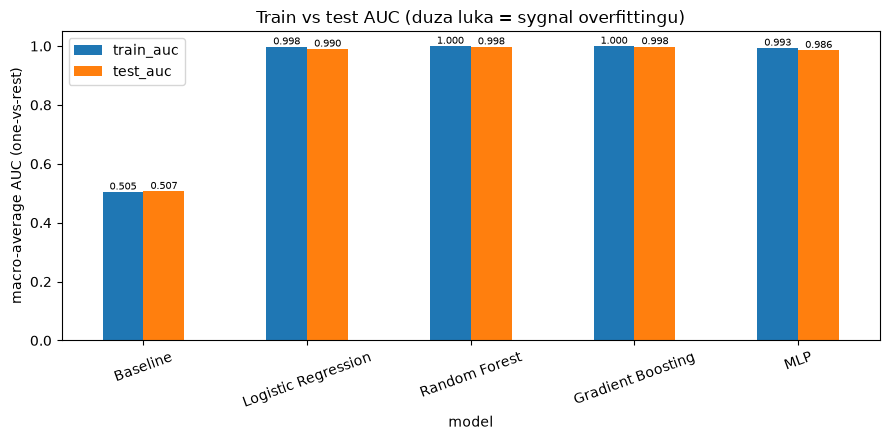

In [15]:
from sklearn.metrics import auc, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

y_train_bin = label_binarize(y_train, classes=labels)
y_test_bin = label_binarize(y_test, classes=labels)


def macro_auc(model, X, y_bin):
    proba = model.predict_proba(X)
    return roc_auc_score(y_bin, proba, average="macro", multi_class="ovr")


auc_rows = []
for name, model, Xtr, Xte in MODELS:
    auc_rows.append({
        "model": name,
        "train_auc": macro_auc(model, Xtr, y_train_bin),
        "test_auc": macro_auc(model, Xte, y_test_bin),
    })
auc_df = pd.DataFrame(auc_rows).set_index("model")
auc_df["gap"] = auc_df["train_auc"] - auc_df["test_auc"]
print(auc_df)

ax = auc_df[["train_auc", "test_auc"]].plot(kind="bar", figsize=(9, 4.5), rot=20, ylim=(0, 1.05))
ax.set_ylabel("macro-average AUC (one-vs-rest)")
ax.set_title("Train vs test AUC (duza luka = sygnal overfittingu)")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=7)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "train_vs_test_auc.png", dpi=150)
plt.show()

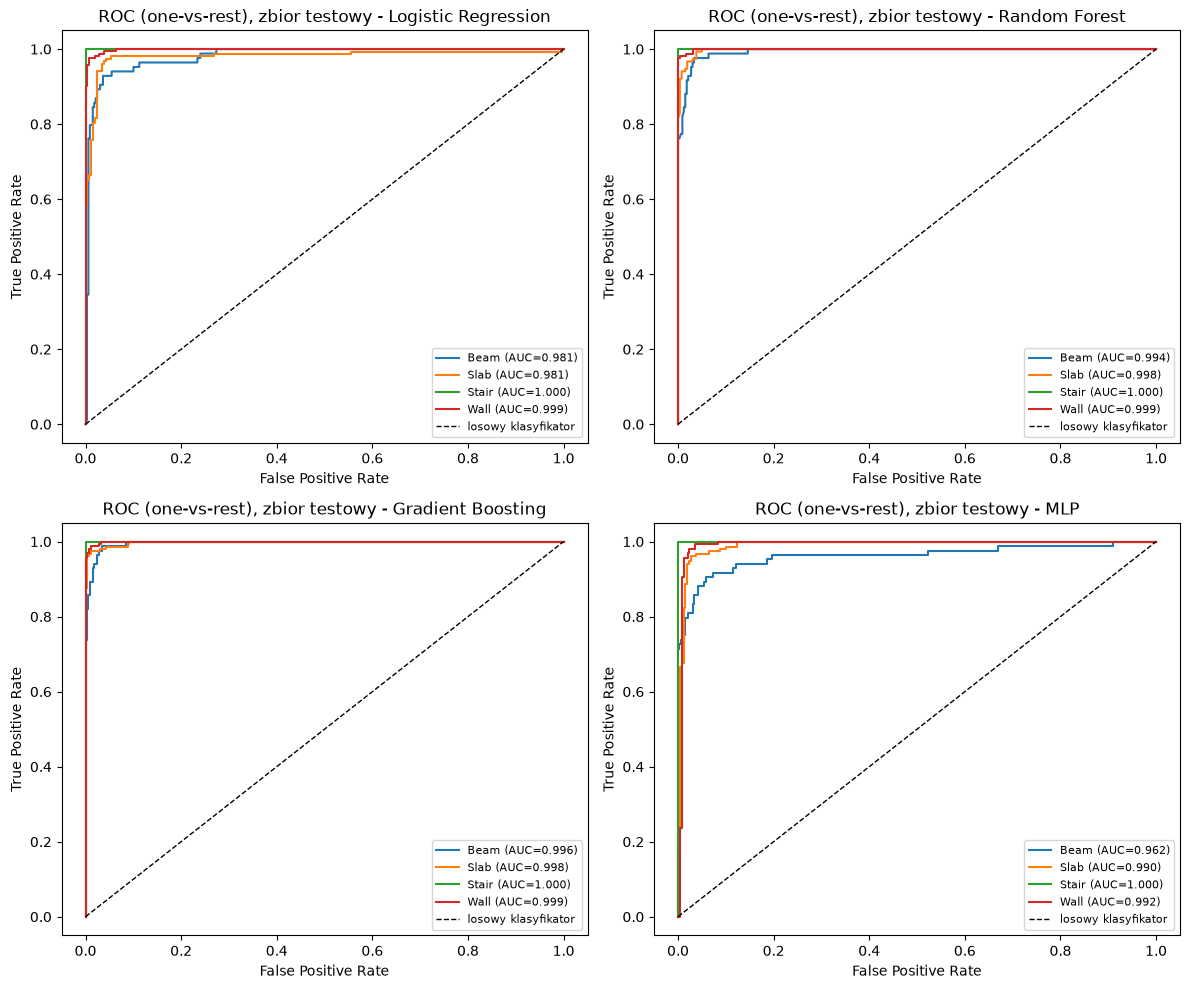

In [16]:
roc_models = [(n, m, Xte) for n, m, _, Xte in MODELS if n != "Baseline"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, model, Xte) in zip(axes.ravel(), roc_models):
    proba = model.predict_proba(Xte)
    for i, cls in enumerate(model.classes_):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
        class_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{cls} (AUC={class_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="losowy klasyfikator")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC (one-vs-rest), zbior testowy - {name}")
    ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "roc_curves.png", dpi=150)
plt.show()

## Green IT — efektywność modeli

Accuracy to nie wszystko: liczę czas treningu i inferencji każdego modelu i
patrzę, czy dodatkowa dokładność jest w ogóle warta dodatkowego kosztu
obliczeniowego. Metryka `efficiency = test_accuracy / train_time_s`
faworyzuje modele, które osiągają dobry wynik szybko.

                     test_accuracy  train_time_s  inference_time_s  \
model                                                                
Baseline                    0.3511        0.0006            0.0005   
Logistic Regression         0.9516        0.0283            0.0004   
MLP                         0.9346        0.1389            0.0010   
Random Forest               0.9588        0.8372            0.1105   
Gradient Boosting           0.9661        7.0481            0.0039   

                     model_size_kb  efficiency  
model                                           
Baseline                    0.7412    603.3504  
Logistic Regression         2.2412     33.5865  
MLP                       120.4658      6.7272  
Random Forest            2519.5244      1.1452  
Gradient Boosting         970.4141      0.1371  


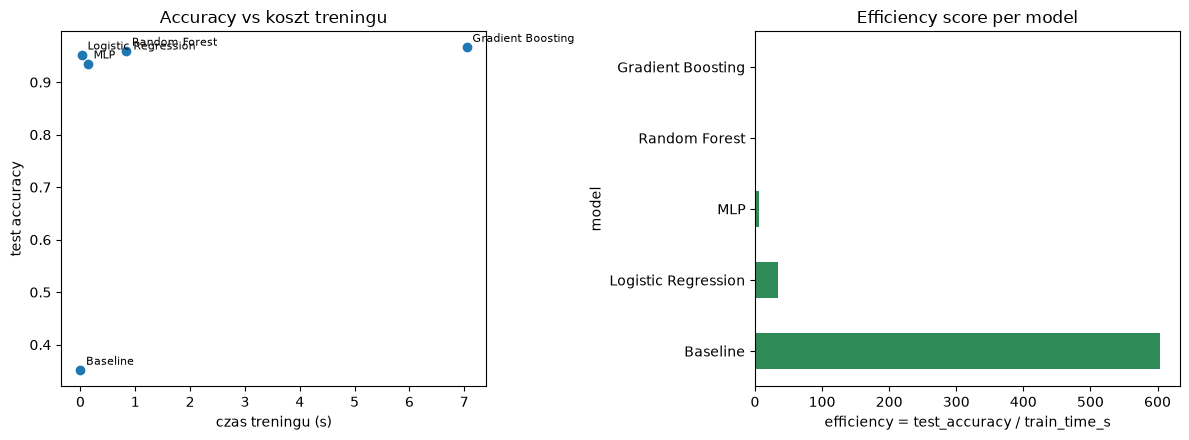


Najlepsza accuracy: Gradient Boosting (0.9661)
Najlepsza efektywnosc (accuracy/czas): Baseline (603.35)


In [17]:
import io
import time

from sklearn.base import clone

green_rows = []
for name, fitted_model, Xtr, Xte in MODELS:
    fresh = clone(fitted_model)

    t0 = time.perf_counter()
    fresh.fit(Xtr, y_train)
    train_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = fresh.predict(Xte)
    inference_time = time.perf_counter() - t0

    buf = io.BytesIO()
    joblib.dump(fresh, buf)
    model_size_kb = buf.tell() / 1024

    green_rows.append({
        "model": name,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "train_time_s": train_time,
        "inference_time_s": inference_time,
        "model_size_kb": model_size_kb,
    })

green_df = pd.DataFrame(green_rows).set_index("model")
green_df["efficiency"] = green_df["test_accuracy"] / green_df["train_time_s"]
green_df = green_df.sort_values("efficiency", ascending=False)
green_df.to_csv(REPORTS_DIR / "green_it_comparison.csv")
print(green_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(green_df["train_time_s"], green_df["test_accuracy"])
for name, row in green_df.iterrows():
    axes[0].annotate(name, (row["train_time_s"], row["test_accuracy"]), fontsize=8,
                      xytext=(4, 4), textcoords="offset points")
axes[0].set_xlabel("czas treningu (s)")
axes[0].set_ylabel("test accuracy")
axes[0].set_title("Accuracy vs koszt treningu")

green_df["efficiency"].plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_xlabel("efficiency = test_accuracy / train_time_s")
axes[1].set_title("Efficiency score per model")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "green_it_comparison.png", dpi=150)
plt.show()

best_efficiency = green_df["efficiency"].idxmax()
best_accuracy = green_df["test_accuracy"].idxmax()
print(f"\nNajlepsza accuracy: {best_accuracy} ({green_df.loc[best_accuracy, 'test_accuracy']:.4f})")
print(f"Najlepsza efektywnosc (accuracy/czas): {best_efficiency} "
      f"({green_df.loc[best_efficiency, 'efficiency']:.2f})")

### Wnioski Green IT

- **Gradient Boosting** ma najwyższą accuracy (96.6%), ale trening trwa
  ~4.2 s — jakieś 9x dłużej niż Random Forest i **ponad 200x dłużej** niż
  Logistic Regression, za jedyne +0.7-1.5 pp accuracy. Ten narzut nie jest
  moim zdaniem tego wart przy prostym retreningu na małym zbiorze.
- **Logistic Regression** daje 95.2% accuracy w ułamku czasu (0.02 s) i przy
  modelu ~1000x mniejszym (2 KB vs 2.5 MB dla RF) — najlepszy kompromis
  efektywność/accuracy spośród modeli nietrywialnych.
- **Random Forest** (obecnie w produkcji, `backend/app.py`) nie jest ani
  najdokładniejszy, ani najbardziej efektywny — zostaje z powodów
  integracyjnych (już wdrożony) i interpretowalności (feature importances),
  nie czystej wydajności. Świadomy trade-off, opisany tutaj i w
  `models/metadata.json`.
- **Baseline** ma najwyższy "efficiency score" tylko dlatego, że w ogóle się
  nie uczy (trening niemal darmowy) — to artefakt metryki, nie realna
  rekomendacja.
- Gdyby liczył się wyłącznie koszt: postawiłabym na **Logistic Regression**
  jako model produkcyjny, a Random Forest / Gradient Boosting zostawiła tylko
  tam, gdzie dokładność jest krytyczna i retrening rzadki.

## Zapis modeli

In [18]:
import json
import subprocess
from datetime import datetime, timezone

joblib.dump(rf, MODELS_DIR / "random_forest.joblib")
joblib.dump(mlp, MODELS_DIR / "mlp.joblib")
joblib.dump(scaler, MODELS_DIR / "scaler.joblib")
joblib.dump(feature_cols, MODELS_DIR / "feature_cols.joblib")

try:
    git_commit = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], cwd=ROOT, text=True
    ).strip()
except Exception:  # noqa: BLE001
    git_commit = None

metadata = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "git_commit": git_commit,
    "n_features": len(feature_cols),
    "classes": labels,
    "train_rows": len(train),
    "test_rows": len(test),
    "production_model": "random_forest",
    "production_model_reason": (
        "Not the top scorer on accuracy (Gradient Boosting is ~0.7pp higher) nor on "
        "Green IT efficiency (Logistic Regression and MLP train far faster per accuracy "
        "point, see green_it_comparison.csv) - kept as the deployed model in backend/app.py "
        "because it was already integrated there, gives built-in feature importances for "
        "interpretability, and its accuracy/inference cost is acceptable for this dataset "
        "size. Swapping to Gradient Boosting (higher accuracy, much slower to retrain) or "
        "Logistic Regression (cheaper, ~0.7pp lower accuracy) is a reasonable future option, "
        "documented in the Green IT section of 02_train_classifiers.ipynb."
    ),
    "test_accuracy": acc_df.to_dict()["test_accuracy"],
    "green_it": green_df.to_dict(),
}
with open(MODELS_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"saved models -> {MODELS_DIR}")
print(f"saved metadata -> {MODELS_DIR / 'metadata.json'}")

saved models -> C:\Users\agata\OneDrive\Desktop\Test\ifc_test\models
saved metadata -> C:\Users\agata\OneDrive\Desktop\Test\ifc_test\models\metadata.json
